# 2 — Обучения YOLO

In [1]:
!pip install -q ultralytics==8.4.49

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00a 0:00:01


In [7]:
import torch
from pathlib import Path

print('CUDA доступен:', torch.cuda.is_available())
print('Кол-во GPU:', torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

DATA_YAML = Path('/kaggle/input/datasets/churka69/lenta-tech-v2/lenta-yolo-dataset/dataset.yaml')
print('dataset.yaml существует:', DATA_YAML.exists())
print(DATA_YAML.read_text())

CUDA доступен: True
Кол-во GPU: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
dataset.yaml существует: True
path: /kaggle/input/lenta-yolo-dataset
train: images/train
val: images/val

nc: 1
names: ['price_tag']



In [11]:
from pathlib import Path
import yaml

DATA_YAML = list(Path('/kaggle/input').rglob('dataset.yaml'))[0]
DATA_ROOT = DATA_YAML.parent

data = yaml.safe_load(DATA_YAML.read_text())

data['path'] = str(DATA_ROOT)

fixed_yaml = Path('/kaggle/working/dataset_fixed.yaml')
fixed_yaml.write_text(
    yaml.safe_dump(data, sort_keys=False, allow_unicode=True)
)

print(fixed_yaml)
print(fixed_yaml.read_text())

/kaggle/working/dataset_fixed.yaml
path: /kaggle/input/datasets/churka69/lenta-tech-v2/lenta-yolo-dataset
train: images/train
val: images/val
nc: 1
names:
- price_tag



In [ ]:
import time
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

t0 = time.time()
results = model.train(
    data=str(fixed_yaml),
    imgsz=1280,
    epochs=60,
    batch=16,
    patience=15,
    mosaic=1.0,
    mixup=0.1,
    perspective=0.001,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    lr0=0.001,
    optimizer='AdamW',
    cache=True,
    workers=4,
    device=0,
    project='/kaggle/working/runs',
    name='tags_v2',
    exist_ok=True,
    verbose=True,
)

map50 = results.results_dict.get('metrics/mAP50(B)', float('nan'))
map50_95 = results.results_dict.get('metrics/mAP50-95(B)', float('nan'))
print(f'mAP@0.5      : {map50:.4f}')
print(f'mAP@0.5-0.95 : {map50_95:.4f}')

New https://pypi.org/project/ultralytics/8.4.50 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tags_

## Графики обучения

results.png


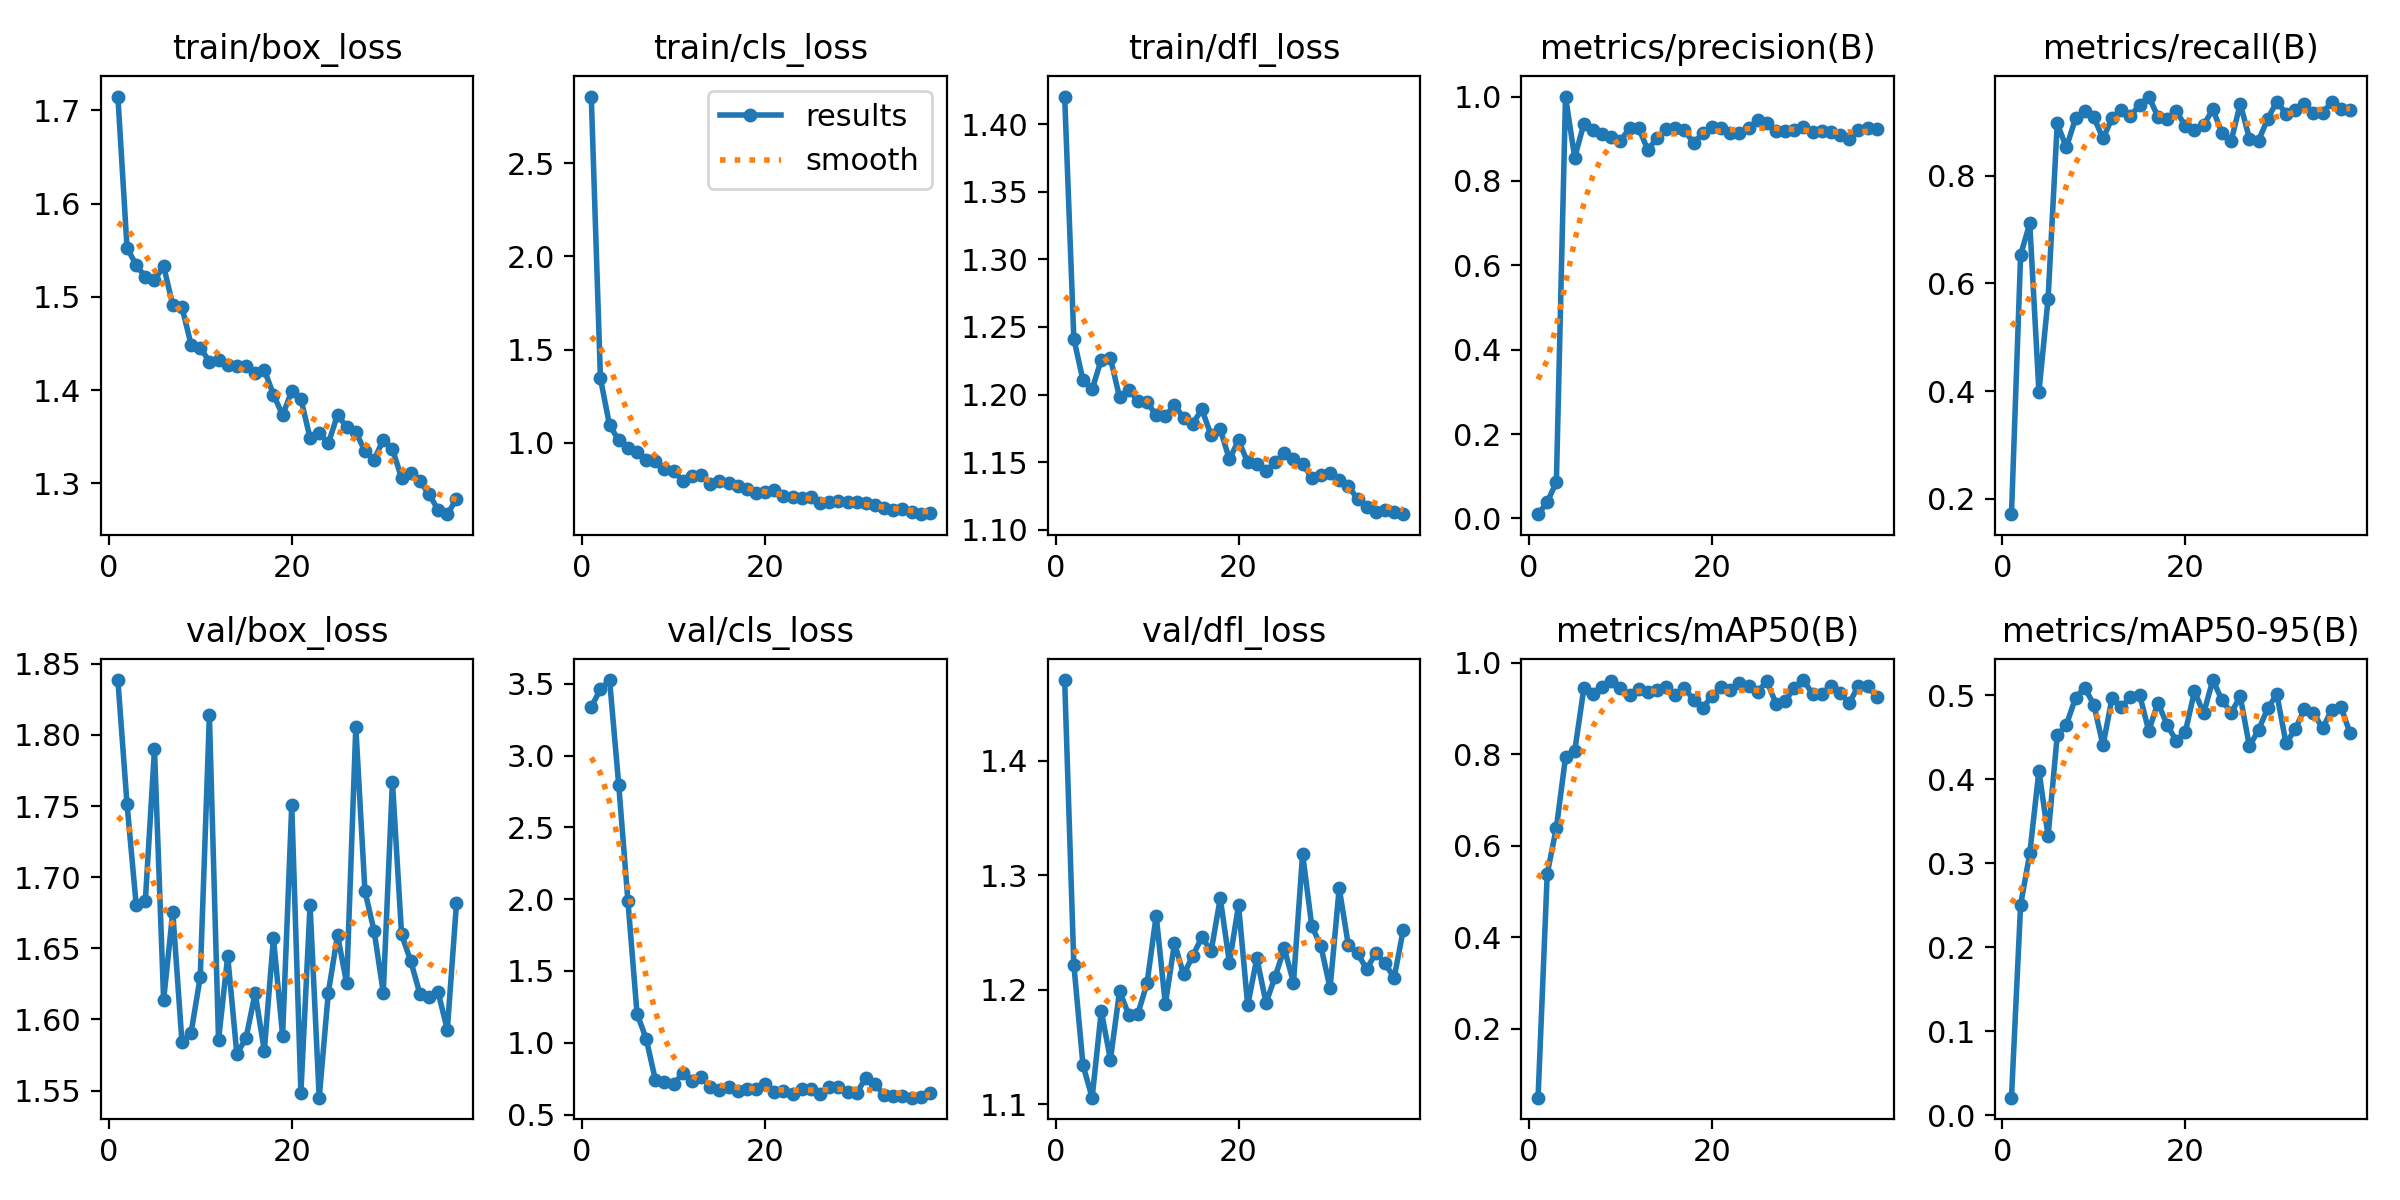

confusion_matrix.png


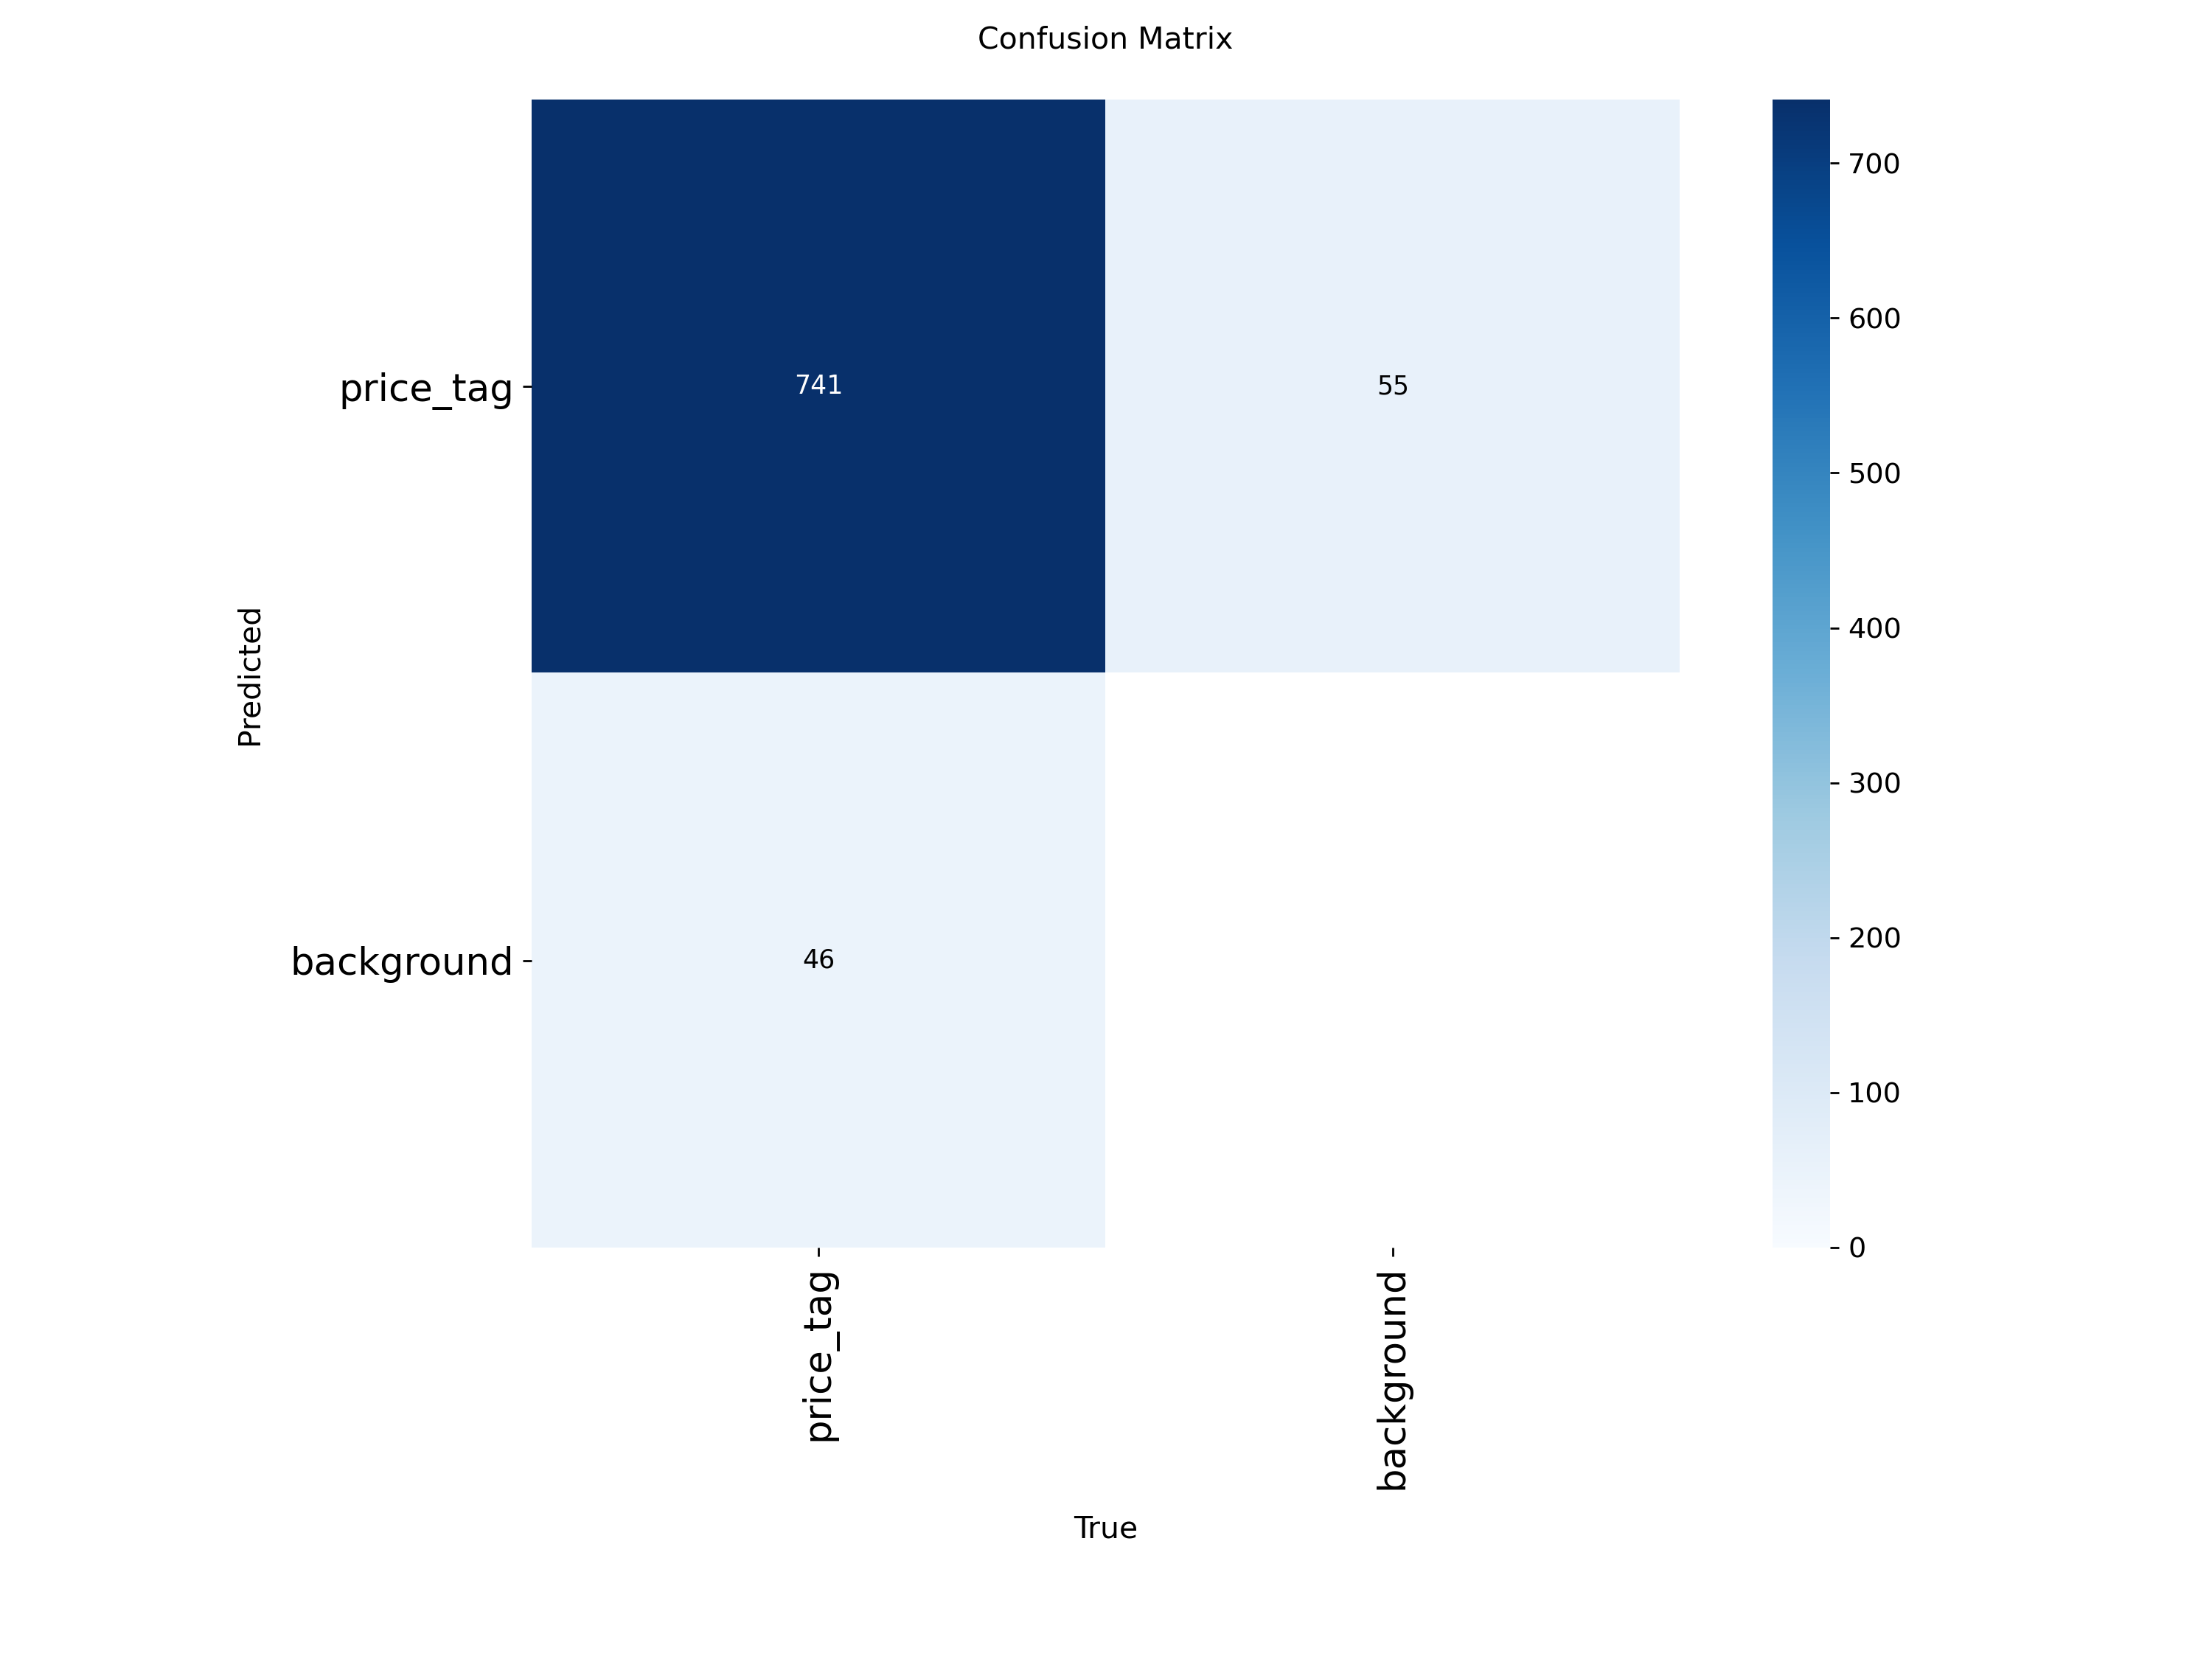

val_batch0_pred.jpg


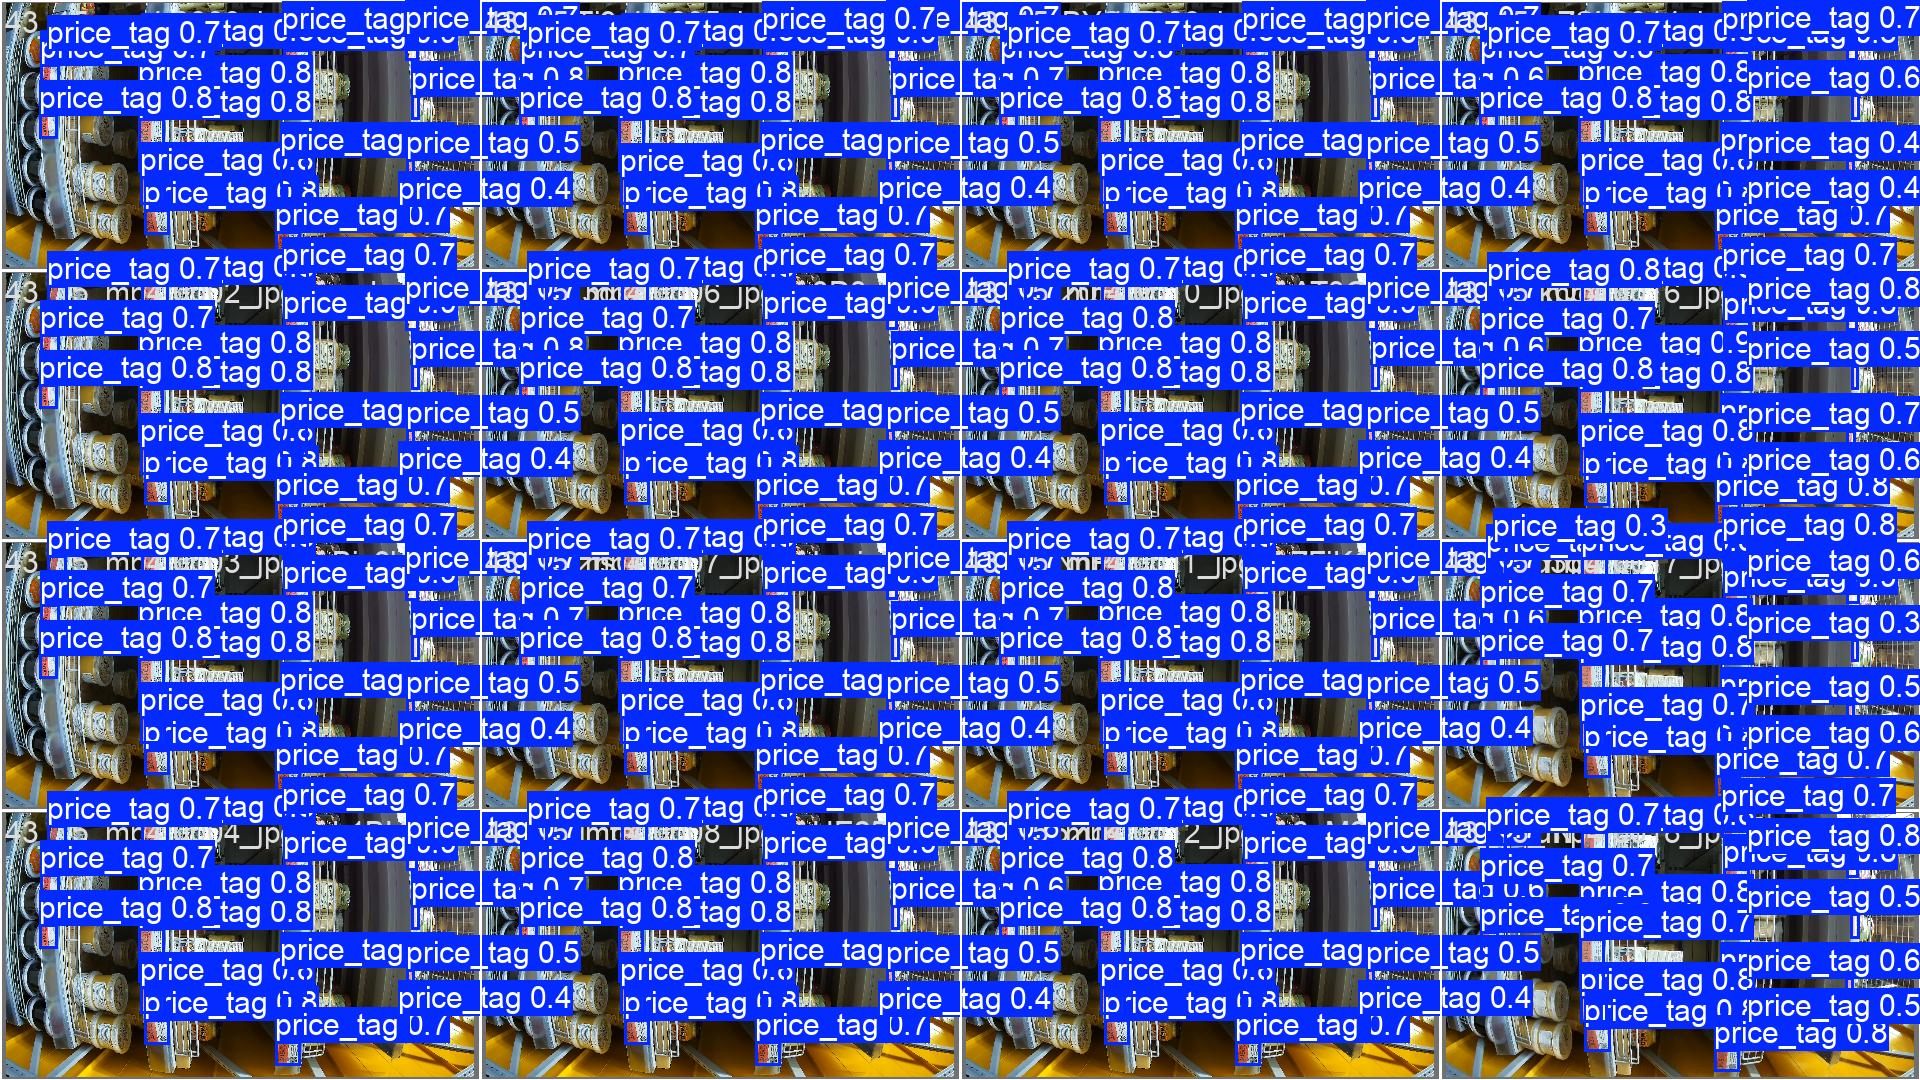

In [17]:
from IPython.display import Image, display

RUN_DIR = Path('/kaggle/working/runs/tags_v2')
for name in ('results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg'):
    p = RUN_DIR / name
    if p.exists():
        print(name)
        display(Image(str(p)))

In [18]:
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
print('best.pt:', BEST_PT, '— exists:', BEST_PT.exists())
if BEST_PT.exists():
    print(f'Размер: {BEST_PT.stat().st_size / 1024 / 1024:.1f} MB')

best.pt: /kaggle/working/runs/tags_v2/weights/best.pt — exists: True
Размер: 5.3 MB
